<a href="https://colab.research.google.com/github/rgrion/adaptativorobotica/blob/main/robotica_arduino.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [ ]:
df = pd.read_excel('robotica_arduino.xlsx')
df

,Código,Tópico Atual,T01,T01_Nota,T01_Dif,T01_AutoC,T01_Trilha,T01_Score,T01R,T01D,...,Consentimento,NotaPre_0_10,Pontuação Final,ux1,ux2,ux3,ux4,ux5,ux6,ux7
0,10005,finalagradecimento.html,5,100,1,3,DESAFIO,86,-1,1,...,Sim,10,9,4,3,3,5,5,2,5
1,10013,finalagradecimento.html,4,80,4,4,DESAFIO,81,-1,1,...,Sim,8,2,5,4,4,1,3,4,2
2,10002,finalagradecimento.html,3,60,3,4,REGULAR,50,-1,-1,...,Sim,5,4,1,1,1,2,1,1,1
3,10001,finalagradecimento.html,5,100,2,3,DESAFIO,86,-1,0,...,Sim,9,7,2,1,2,1,1,4,4
4,10004,finalagradecimento.html,3,60,3,1,REGULAR,50,-1,-1,...,Sim,9,7,1,3,5,2,5,5,5
5,10012,finalagradecimento.html,4,80,4,2,REGULAR,38,-1,-1,...,Sim,6,7,3,4,5,4,5,5,4
6,10011,finalagradecimento.html,3,60,5,2,REFORCO,14,3,-1,...,Sim,5,6,3,2,5,3,3,5,4
7,10010,finalagradecimento.html,5,100,5,2,REGULAR,38,-1,-1,...,Sim,7,10,3,3,4,4,5,5,4
8,10008,finalagradecimento.html,5,100,4,4,DESAFIO,81,-1,1,...,Sim,7,7,3,3,3,3,3,3,3
9,10007,finalagradecimento.html,5,100,5,4,DESAFIO,81,-1,1,...,Sim,7,6,3,3,3,4,4,4,5


In [ ]:
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 64 columns):
 #   Column                                                   Non-Null Count  Dtype 
---  ------                                                   --------------  ----- 
 0   Código                                                   14 non-null     int64 
 1   Tópico Atual                                             14 non-null     object
 2   T01                                                      14 non-null     int64 
 3   T01_Nota                                                 14 non-null     int64 
 4   T01_Dif                                                  14 non-null     int64 
 5   T01_AutoC                                                14 non-null     int64 
 6   T01_Trilha                                               14 non-null     object
 7   T01_Score                                                14 non-null     int64 
 8   T01R                                      

,Código,Tópico Atual,T01,T01_Nota,T01_Dif,T01_AutoC,T01_Trilha,T01_Score,T01R,T01D,...,Consentimento,NotaPre_0_10,Pontuação Final,ux1,ux2,ux3,ux4,ux5,ux6,ux7
count,14.000000,14,14.000000,14.000000,14.000000,14.000000,14,14.000000,14.000000,14.000000,...,14,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000
unique,NaN,1,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,finalagradecimento.html,NaN,NaN,NaN,NaN,DESAFIO,NaN,NaN,NaN,...,Sim,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,14,NaN,NaN,NaN,NaN,9,NaN,NaN,NaN,...,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,10009.071429,NaN,4.214286,84.285714,3.500000,2.928571,NaN,66.714286,-0.714286,0.071429,...,NaN,7.357143,6.500000,3.071429,2.928571,3.571429,2.928571,3.714286,3.500000,3.785714
std,5.210408,NaN,0.801784,16.035675,1.286019,1.141139,NaN,23.740354,1.069045,0.916875,...,NaN,1.446861,1.911504,1.206666,1.071612,1.222500,1.206666,1.437336,1.344504,1.251373
min,10001.000000,NaN,3.000000,60.000000,1.000000,1.000000,NaN,14.000000,-1.000000,-1.000000,...,NaN,5.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,10005.250000,NaN,4.000000,80.000000,3.000000,2.000000,NaN,50.000000,-1.000000,-1.000000,...,NaN,7.000000,6.000000,3.000000,3.000000,3.000000,2.000000,3.000000,2.250000,3.000000
50%,10009.000000,NaN,4.000000,80.000000,3.500000,3.000000,NaN,81.000000,-1.000000,0.000000,...,NaN,7.000000,7.000000,3.000000,3.000000,3.500000,3.000000,4.000000,4.000000,4.000000
75%,10012.750000,NaN,5.000000,100.000000,4.750000,4.000000,NaN,81.000000,-1.000000,1.000000,...,NaN,8.000000,7.000000,3.750000,3.000000,4.750000,4.000000,5.000000,4.750000,5.000000


In [ ]:
colunas_diag = [
    'Faixa Etária',
    'Gênero',
    'Grau de escolaridade',
    'Você tem acesso à internet em casa?',
    'Principal dispositivo usado para estudar',
    'Como costuma estudar?',
    'Já teve contato com programação/eletrônica?',
    'Você já usou Arduino ou Tinkercad?',
    'Onde você costuma estudar sobre tecnologia?',
    'Com que frequência estuda tecnologia por conta própria?',
    'Como você se sente ao aprender algo novo em tecnologia?',
    'Qual é o seu principal objetivo com este curso?',
    'NotaPre_0_10'
]

df_diag = df[colunas_diag].copy()
df_diag.head()


,Faixa Etária,Gênero,Grau de escolaridade,Você tem acesso à internet em casa?,Principal dispositivo usado para estudar,Como costuma estudar?,Já teve contato com programação/eletrônica?,Você já usou Arduino ou Tinkercad?,Onde você costuma estudar sobre tecnologia?,Com que frequência estuda tecnologia por conta própria?,Como você se sente ao aprender algo novo em tecnologia?,Qual é o seu principal objetivo com este curso?,NotaPre_0_10
0,14 anos,Feminino,Ensino Fundamental,Sim,Computador,Sozinho(a),Sim,"Sim, os dois",Redes sociais,Raramente,Empolgado(a),aprimorar meus conhecimentos básicos sobre rob...,10
1,13 anos,Masculino,Ensino Fundamental,Sim,Celular,Sozinho(a),Sim,Nunca usei,Escola/Professor,Nunca,Empolgado(a),aprender coisas novas,8
2,13 anos,Masculino,Ensino Fundamental,Sim,Celular,Sozinho(a),Sim,"Sim, os dois",Escola/Professor,Algumas vezes por semana,Empolgado(a),aprender coisas novas para aprendermos mais,5
3,14 anos,Masculino,Ensino Fundamental,Não,Celular,Sozinho(a),Sim,Nunca usei,YouTube,Raramente,Curioso(a),aprender novas coisas,9
4,13 anos,Masculino,Ensino Fundamental,Sim,Celular,Outro,Não,Nunca usei,Outro,Nunca,Indiferente,montar um robo,9


In [ ]:
df_diag_cat = df_diag.drop(columns=['NotaPre_0_10'])
df_diag_num = df_diag[['NotaPre_0_10']].copy()

# Categorias: preencher NA com rótulo padrão
df_diag_cat = df_diag_cat.fillna('Não informado')

# Numérica: preencher NA com média (ou use dropna)
df_diag_num['NotaPre_0_10'] = df_diag_num['NotaPre_0_10'].fillna(df_diag_num['NotaPre_0_10'].mean())

# Rejuntar
df_diag_clean = pd.concat([df_diag_cat, df_diag_num], axis=1)
df_diag_clean.head()


,Faixa Etária,Gênero,Grau de escolaridade,Você tem acesso à internet em casa?,Principal dispositivo usado para estudar,Como costuma estudar?,Já teve contato com programação/eletrônica?,Você já usou Arduino ou Tinkercad?,Onde você costuma estudar sobre tecnologia?,Com que frequência estuda tecnologia por conta própria?,Como você se sente ao aprender algo novo em tecnologia?,Qual é o seu principal objetivo com este curso?,NotaPre_0_10
0,14 anos,Feminino,Ensino Fundamental,Sim,Computador,Sozinho(a),Sim,"Sim, os dois",Redes sociais,Raramente,Empolgado(a),aprimorar meus conhecimentos básicos sobre rob...,10
1,13 anos,Masculino,Ensino Fundamental,Sim,Celular,Sozinho(a),Sim,Nunca usei,Escola/Professor,Nunca,Empolgado(a),aprender coisas novas,8
2,13 anos,Masculino,Ensino Fundamental,Sim,Celular,Sozinho(a),Sim,"Sim, os dois",Escola/Professor,Algumas vezes por semana,Empolgado(a),aprender coisas novas para aprendermos mais,5
3,14 anos,Masculino,Ensino Fundamental,Não,Celular,Sozinho(a),Sim,Nunca usei,YouTube,Raramente,Curioso(a),aprender novas coisas,9
4,13 anos,Masculino,Ensino Fundamental,Sim,Celular,Outro,Não,Nunca usei,Outro,Nunca,Indiferente,montar um robo,9


In [ ]:
X_cat = pd.get_dummies(df_diag_cat, drop_first=True)  # evita multicolinearidade
X_num = df_diag_num[['NotaPre_0_10']]

X = pd.concat([X_cat, X_num], axis=1)

print(X.shape)
X.head()


(14, 36)


,Faixa Etária_13 anos,Faixa Etária_14 anos,Faixa Etária_17 anos,Gênero_Masculino,Grau de escolaridade_Ensino Médio,Você tem acesso à internet em casa?_Sim,Principal dispositivo usado para estudar_Computador,Principal dispositivo usado para estudar_Outro,Como costuma estudar?_Em sala de aula,Como costuma estudar?_Outro,...,"Qual é o seu principal objetivo com este curso?_aprimorar meus conhecimentos básicos sobre robótica, e chegar a construir um robô",Qual é o seu principal objetivo com este curso?_conseguir fazer robo,Qual é o seu principal objetivo com este curso?_conseguir fazer um robo simples,Qual é o seu principal objetivo com este curso?_consuir fazer robo,Qual é o seu principal objetivo com este curso?_fazer meu primeiro robô,"Qual é o seu principal objetivo com este curso?_fazer muitas coisas novas, aprender mais.",Qual é o seu principal objetivo com este curso?_fazer um robo de metal,Qual é o seu principal objetivo com este curso?_montar um robo,Qual é o seu principal objetivo com este curso?_para a pender mais neste mundo de robos,NotaPre_0_10
0,False,True,False,False,False,True,True,False,False,False,...,True,False,False,False,False,False,False,False,False,10
1,True,False,False,True,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,8
2,True,False,False,True,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,5
3,False,True,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,9
4,True,False,False,True,False,True,False,False,False,True,...,False,False,False,False,False,False,False,True,False,9


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled.shape


(14, 36)

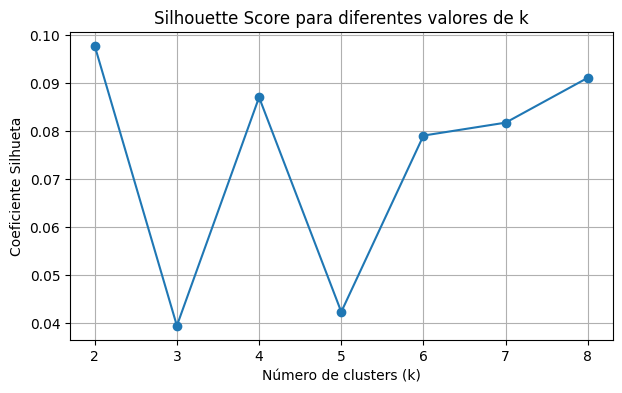

[np.float64(0.09783622127800849),
 np.float64(0.03935819975272015),
 np.float64(0.08706243186631128),
 np.float64(0.042246483626671195),
 np.float64(0.0790702844881354),
 np.float64(0.08177151695634044),
 np.float64(0.09114868538839231)]

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

K_range = range(2, 9)  # por exemplo, k de 2 até 8

silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(7,4))
plt.plot(list(K_range), silhouette_scores, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Coeficiente Silhueta')
plt.title('Silhouette Score para diferentes valores de k')
plt.grid(True)
plt.show()

silhouette_scores

In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df['cluster_diag'] = clusters  # salva a qual cluster cada aluno pertence
df[['cluster_diag', 'NotaPre_0_10']]

,cluster_diag,NotaPre_0_10
0,0,10
1,1,8
2,1,5
3,0,9
4,1,9
5,1,6
6,1,5
7,1,7
8,1,7
9,0,7


In [ ]:
df['cluster_diag'].value_counts()

,count
cluster_diag,
1,9
0,5


In [ ]:
df.groupby('cluster_diag')['NotaPre_0_10'].agg(['count', 'mean', 'std'])

,count,mean,std
cluster_diag,,,
0,5,8.200000,1.303840
1,9,6.888889,1.364225


In [ ]:
def resumo_categorico_por_cluster(col):
    tab = pd.crosstab(df[col], df['cluster_diag'], normalize='columns') * 100
    return tab.round(1)

# Exemplo com algumas variáveis:
print("Faixa Etária (%) por cluster:")
display(resumo_categorico_por_cluster('Faixa Etária'))

print("Gênero (%) por cluster:")
display(resumo_categorico_por_cluster('Gênero'))

print("Já teve contato com programação/eletrônica? (%) por cluster:")
display(resumo_categorico_por_cluster('Já teve contato com programação/eletrônica?'))


Faixa Etária (%) por cluster:


cluster_diag,0,1
Faixa Etária,,
12 anos,40.0,44.4
13 anos,0.0,44.4
14 anos,40.0,11.1
17 anos,20.0,0.0


Gênero (%) por cluster:


cluster_diag,0,1
Gênero,,
Feminino,80.0,66.7
Masculino,20.0,33.3


Já teve contato com programação/eletrônica? (%) por cluster:


cluster_diag,0,1
Já teve contato com programação/eletrônica?,,
Não,40.0,77.8
Sim,60.0,22.2


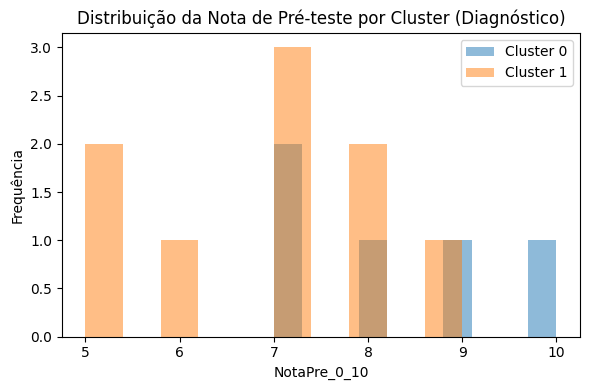

In [ ]:
plt.figure(figsize=(6,4))
for c in sorted(df['cluster_diag'].unique()):
    subset = df[df['cluster_diag'] == c]['NotaPre_0_10']
    plt.hist(subset, bins=10, alpha=0.5, label=f'Cluster {c}')

plt.xlabel('NotaPre_0_10')
plt.ylabel('Frequência')
plt.title('Distribuição da Nota de Pré-teste por Cluster (Diagnóstico)')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
from scipy.stats import shapiro

# Separar os dados da NotaPre por cluster
cluster0 = df.loc[df['cluster_diag'] == 0, 'NotaPre_0_10'].dropna()
cluster1 = df.loc[df['cluster_diag'] == 1, 'NotaPre_0_10'].dropna()

print("Cluster 0 - tamanho:", len(cluster0), "valores:", cluster0.values)
print("Cluster 1 - tamanho:", len(cluster1), "valores:", cluster1.values)

# Teste de normalidade Shapiro-Wilk
stat0, p0 = shapiro(cluster0)
stat1, p1 = shapiro(cluster1)

print("\nShapiro-Wilk - Cluster 0:")
print(f"  Estatística W = {stat0:.4f}, p-valor = {p0:.4f}")

print("\nShapiro-Wilk - Cluster 1:")
print(f"  Estatística W = {stat1:.4f}, p-valor = {p1:.4f}")

# Interpretação básica
alpha = 0.05
print("\nInterpretação (α = 0.05):")
print("Cluster 0:", "Distribuição aproximadamente normal" if p0 > alpha else "Desvio da normalidade")
print("Cluster 1:", "Distribuição aproximadamente normal" if p1 > alpha else "Desvio da normalidade")

Cluster 0 - tamanho: 5 valores: [10  9  7  7  8]
Cluster 1 - tamanho: 9 valores: [8 5 9 6 5 7 7 7 8]

Shapiro-Wilk - Cluster 0:
  Estatística W = 0.9020, p-valor = 0.4211

Shapiro-Wilk - Cluster 1:
  Estatística W = 0.9314, p-valor = 0.4944

Interpretação (α = 0.05):
Cluster 0: Distribuição aproximadamente normal
Cluster 1: Distribuição aproximadamente normal


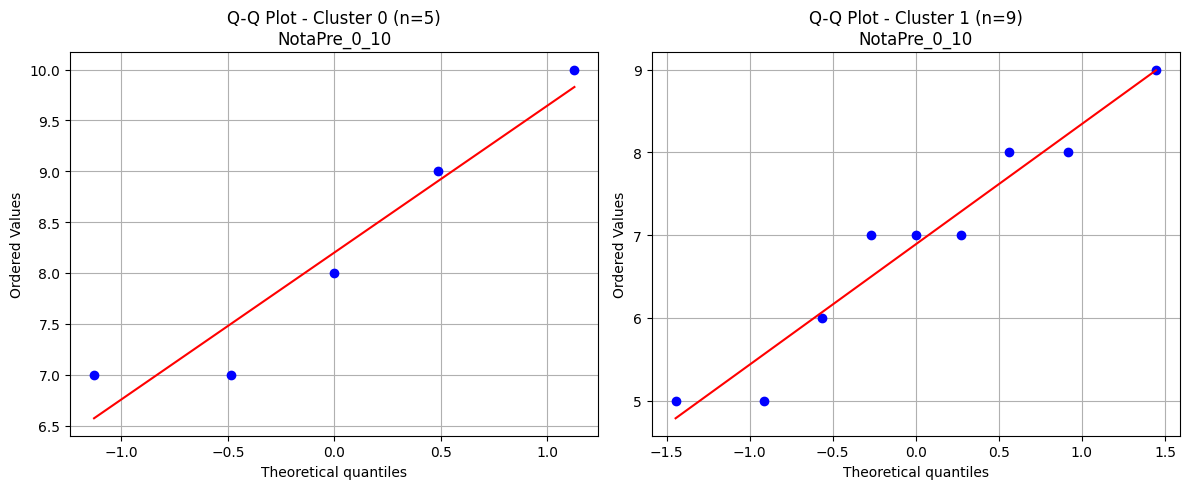

In [ ]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Criação da figura com dois gráficos lado a lado
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# ---------- Cluster 0 ----------
stats.probplot(cluster0, dist="norm", plot=axs[0])
axs[0].set_title("Q-Q Plot - Cluster 0 (n=5)\nNotaPre_0_10")
axs[0].grid(True)

# ---------- Cluster 1 ----------
stats.probplot(cluster1, dist="norm", plot=axs[1])
axs[1].set_title("Q-Q Plot - Cluster 1 (n=9)\nNotaPre_0_10")
axs[1].grid(True)

plt.tight_layout()
plt.show()


In [ ]:
from scipy.stats import levene

stat_levene, p_levene = levene(cluster0, cluster1)

print("Teste de Levene (homogeneidade das variâncias)")
print(f"Estatística = {stat_levene:.4f}, p-valor = {p_levene:.4f}")

alpha = 0.05
if p_levene > alpha:
    print("\nConclusão: variâncias homogêneas (p > 0.05). Use t-test padrão (equal_var=True).")
else:
    print("\nConclusão: variâncias diferentes (p <= 0.05). Use Welch t-test (equal_var=False).")

Teste de Levene (homogeneidade das variâncias)
Estatística = 0.0000, p-valor = 1.0000

Conclusão: variâncias homogêneas (p > 0.05). Use t-test padrão (equal_var=True).


In [ ]:
from scipy.stats import ttest_ind

t_stat, p_val = ttest_ind(cluster0, cluster1, equal_var=True)

print("T-test independente (variâncias iguais)")
print(f"t = {t_stat:.4f}, p-valor = {p_val:.4f}")

alpha = 0.05
if p_val < alpha:
    print("\nConclusão: diferença significativa entre os clusters (p < 0.05)")
else:
    print("\nConclusão: não há diferença significativa entre os clusters (p ≥ 0.05)")

T-test independente (variâncias iguais)
t = 1.7485, p-valor = 0.1059

Conclusão: não há diferença significativa entre os clusters (p ≥ 0.05)


In [ ]:
# Separar notas finais por cluster
f0 = df[df['cluster_diag'] == 0]['Pontuação Final'].dropna()
f1 = df[df['cluster_diag'] == 1]['Pontuação Final'].dropna()

print("Cluster 0 - Pontuação Final:", f0.values)
print("Cluster 1 - Pontuação Final:", f1.values)

Cluster 0 - Pontuação Final: [9 7 6 6 7]
Cluster 1 - Pontuação Final: [ 2  4  7  7  6 10  7  6  7]


In [ ]:
from scipy.stats import shapiro

stat_f0, p_f0 = shapiro(f0)
stat_f1, p_f1 = shapiro(f1)

print("\nShapiro-Wilk - Cluster 0 (Pontuação Final):")
print(f"  W = {stat_f0:.4f}, p = {p_f0:.4f}")

print("\nShapiro-Wilk - Cluster 1 (Pontuação Final):")
print(f"  W = {stat_f1:.4f}, p = {p_f1:.4f}")

alpha = 0.05
print("\nInterpretação (α = 0.05):")
print("Cluster 0:", "Normal" if p_f0 > alpha else "Não normal")
print("Cluster 1:", "Normal" if p_f1 > alpha else "Não normal")



Shapiro-Wilk - Cluster 0 (Pontuação Final):
  W = 0.8327, p = 0.1458

Shapiro-Wilk - Cluster 1 (Pontuação Final):
  W = 0.9027, p = 0.2679

Interpretação (α = 0.05):
Cluster 0: Normal
Cluster 1: Normal


In [ ]:
from scipy.stats import levene

stat_lev, p_lev = levene(f0, f1)

print("Teste de Levene (Pontuação Final)")
print(f"Estatística = {stat_lev:.4f}, p-valor = {p_lev:.4f}")

alpha = 0.05
if p_lev > alpha:
    print("\nConclusão: variâncias homogêneas → usar t-test padrão (equal_var=True)")
else:
    print("\nConclusão: variâncias diferentes → usar Welch t-test (equal_var=False)")


Teste de Levene (Pontuação Final)
Estatística = 0.5520, p-valor = 0.4718

Conclusão: variâncias homogêneas → usar t-test padrão (equal_var=True)


In [ ]:
from scipy.stats import ttest_ind

t_stat_final, p_val_final = ttest_ind(f0, f1, equal_var=True)

print("T-test independente (Pontuação Final)")
print(f"t = {t_stat_final:.4f}, p-valor = {p_val_final:.4f}")

alpha = 0.05
if p_val_final < alpha:
    print("\nConclusão: diferença significativa entre os clusters (p < 0.05)")
else:
    print("\nConclusão: não há diferença significativa entre os clusters (p ≥ 0.05)")

T-test independente (Pontuação Final)
t = 0.7157, p-valor = 0.4879

Conclusão: não há diferença significativa entre os clusters (p ≥ 0.05)


In [ ]:
import numpy as np

# médias e desvios padrão
mean_f0 = np.mean(f0)
mean_f1 = np.mean(f1)

std_f0 = np.std(f0, ddof=1)
std_f1 = np.std(f1, ddof=1)

# tamanhos
n0 = len(f0)
n1 = len(f1)

# desvio padrão combinado (pooled)
pooled_std_final = np.sqrt(((n0 - 1)*std_f0**2 + (n1 - 1)*std_f1**2) / (n0 + n1 - 2))

cohens_d_final = (mean_f0 - mean_f1) / pooled_std_final

print(f"Cohen's d (Pontuação Final) = {cohens_d_final:.4f}")

# Interpretação
if abs(cohens_d_final) < 0.2:
    print("Tamanho de efeito: MUITO pequeno (desprezível)")
elif abs(cohens_d_final) < 0.5:
    print("Tamanho de efeito: pequeno")
elif abs(cohens_d_final) < 0.8:
    print("Tamanho de efeito: moderado")
else:
    print("Tamanho de efeito: grande")

Cohen's d (Pontuação Final) = 0.3992
Tamanho de efeito: pequeno


In [ ]:
trilhas_cols = ['T01_Trilha', 'T02_Trilha', 'T03_Trilha', 'T04_Trilha', 'T05_Trilha']

for col in trilhas_cols:
    print(f"\n=== Distribuição percentual da trilha no {col} ===")
    tabela = pd.crosstab(df['cluster_diag'], df[col], normalize='index') * 100
    display(tabela.round(1))




=== Distribuição percentual da trilha no T01_Trilha ===


T01_Trilha,DESAFIO,REFORCO,REGULAR
cluster_diag,,,
0,100.0,0.0,0.0
1,44.4,11.1,44.4



=== Distribuição percentual da trilha no T02_Trilha ===


T02_Trilha,DESAFIO,REFORCO,REGULAR
cluster_diag,,,
0,80.0,0.0,20.0
1,33.3,11.1,55.6



=== Distribuição percentual da trilha no T03_Trilha ===


T03_Trilha,DESAFIO,REFORCO,REGULAR
cluster_diag,,,
0,40.0,60.0,0.0
1,11.1,55.6,33.3



=== Distribuição percentual da trilha no T04_Trilha ===


T04_Trilha,DESAFIO,REFORCO,REGULAR
cluster_diag,,,
0,20.0,40.0,40.0
1,11.1,66.7,22.2



=== Distribuição percentual da trilha no T05_Trilha ===


T05_Trilha,DESAFIO,REFORCO,REGULAR
cluster_diag,,,
0,40.0,20.0,40.0
1,33.3,55.6,11.1


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

trilhas_cols = ['T01_Trilha', 'T02_Trilha', 'T03_Trilha', 'T04_Trilha', 'T05_Trilha']
trilhas_labels = ['DESAFIO', 'REFORCO', 'REGULAR']

def dist_trilhas_por_cluster(df, cluster_id):
    # cria dataframe vazio com tópicos nas linhas e tipos de trilha nas colunas
    dist = pd.DataFrame(0.0, index=trilhas_cols, columns=trilhas_labels)

    df_cluster = df[df['cluster_diag'] == cluster_id]

    for col in trilhas_cols:
        # distribuição percentual da trilha naquele tópico, dentro do cluster
        s = df_cluster[col].value_counts(normalize=True) * 100
        for trilha, perc in s.items():
            if trilha in dist.columns:
                dist.loc[col, trilha] = perc

    # renomear o índice para ficar mais bonitinho no gráfico
    dist.index = [col.replace('_Trilha', '') for col in dist.index]

    return dist

dist0 = dist_trilhas_por_cluster(df, 0)
dist1 = dist_trilhas_por_cluster(df, 1)

print("Cluster 0 - distribuição de trilhas (%):")
display(dist0.round(1))

print("\nCluster 1 - distribuição de trilhas (%):")
display(dist1.round(1))



Cluster 0 - distribuição de trilhas (%):


,DESAFIO,REFORCO,REGULAR
T01,100.0,0.0,0.0
T02,80.0,0.0,20.0
T03,40.0,60.0,0.0
T04,20.0,40.0,40.0
T05,40.0,20.0,40.0



Cluster 1 - distribuição de trilhas (%):


,DESAFIO,REFORCO,REGULAR
T01,44.4,11.1,44.4
T02,33.3,11.1,55.6
T03,11.1,55.6,33.3
T04,11.1,66.7,22.2
T05,33.3,55.6,11.1


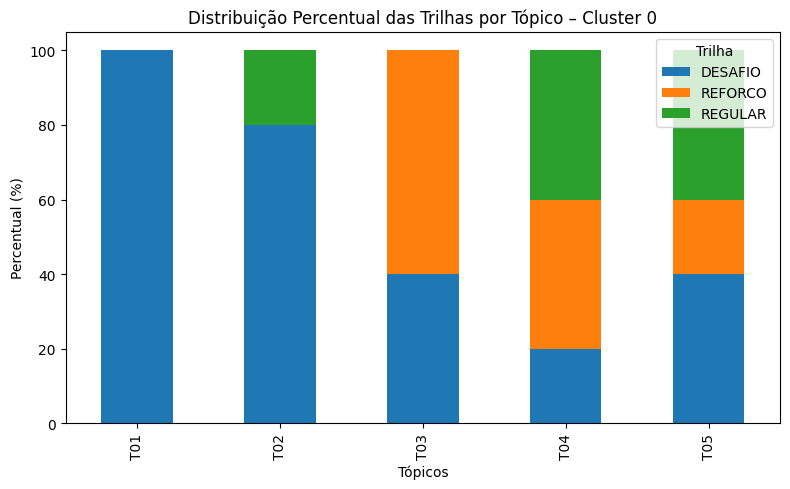

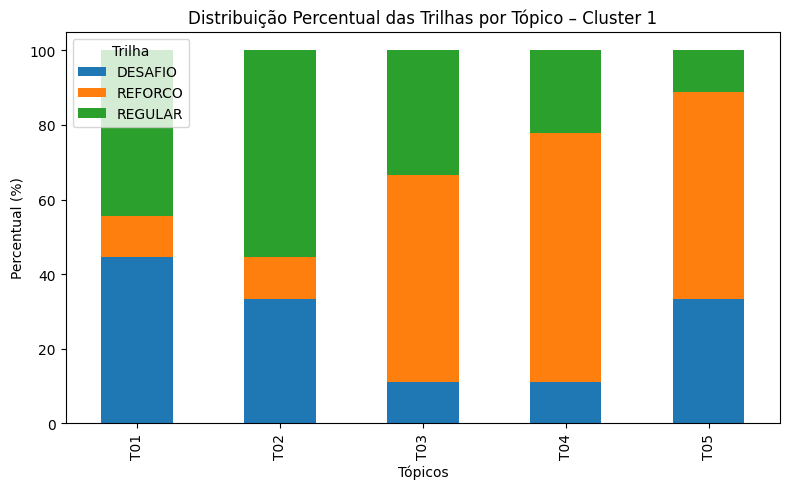

In [ ]:
# --------- Gráfico Cluster 0 ---------
ax = dist0.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)
plt.title("Distribuição Percentual das Trilhas por Tópico – Cluster 0")
plt.ylabel("Percentual (%)")
plt.xlabel("Tópicos")
plt.legend(title="Trilha")
plt.tight_layout()
plt.show()

# --------- Gráfico Cluster 1 ---------
ax = dist1.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)
plt.title("Distribuição Percentual das Trilhas por Tópico – Cluster 1")
plt.ylabel("Percentual (%)")
plt.xlabel("Tópicos")
plt.legend(title="Trilha")
plt.tight_layout()
plt.show()


In [ ]:
# Selecionar apenas colunas de notas
nota_cols = ['T01_Nota', 'T02_Nota', 'T03_Nota', 'T04_Nota', 'T05_Nota']

# Calcular média por cluster
medias_notas = df.groupby('cluster_diag')[nota_cols].mean().round(1)

print("Média das notas dos tópicos por cluster:")
display(medias_notas)


Média das notas dos tópicos por cluster:


,T01_Nota,T02_Nota,T03_Nota,T04_Nota,T05_Nota
cluster_diag,,,,,
0,96.0,84.0,56.0,56.0,68.0
1,77.8,82.2,57.8,37.8,53.3


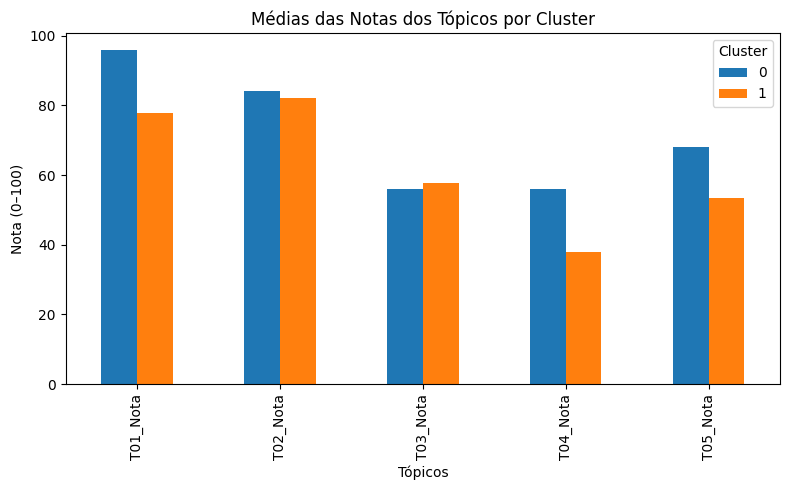

In [ ]:
medias_notas.T.plot(kind='bar', figsize=(8,5))
plt.title("Médias das Notas dos Tópicos por Cluster")
plt.ylabel("Nota (0–100)")
plt.xlabel("Tópicos")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


In [ ]:
# Selecionar colunas de dificuldade (metacognitivo)
dif_cols = ['T01_Dif', 'T02_Dif', 'T03_Dif', 'T04_Dif', 'T05_Dif']

# Calcular médias por cluster
medias_dif = df.groupby('cluster_diag')[dif_cols].mean().round(2)

print("Média da Dificuldade (Metacognitivo) por cluster:")
display(medias_dif)


Média da Dificuldade (Metacognitivo) por cluster:


,T01_Dif,T02_Dif,T03_Dif,T04_Dif,T05_Dif
cluster_diag,,,,,
0,3.00,2.80,4.0,3.40,3.20
1,3.78,4.78,4.0,3.67,4.22


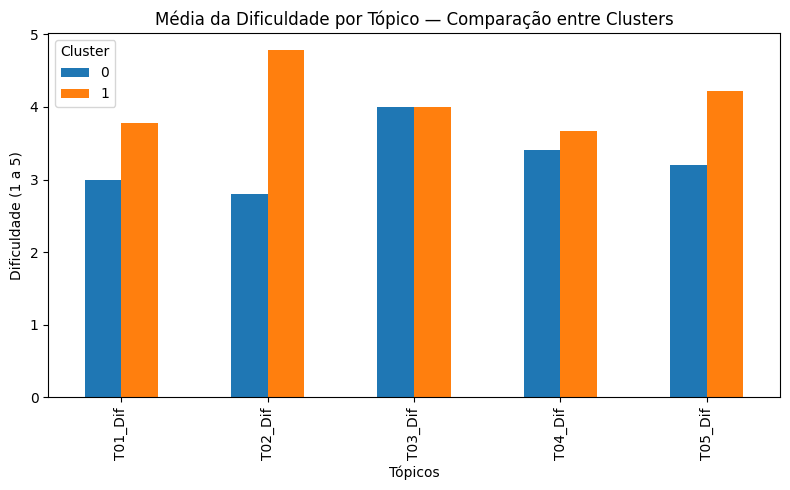

In [ ]:
medias_dif.T.plot(kind='bar', figsize=(8,5))
plt.title("Média da Dificuldade por Tópico — Comparação entre Clusters")
plt.ylabel("Dificuldade (1 a 5)")
plt.xlabel("Tópicos")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


In [ ]:
# Selecionar colunas de autoconfiança (afetivo)
auto_cols = ['T01_AutoC', 'T02_AutoC', 'T03_AutoC', 'T04_AutoC', 'T05_AutoC']

# Calcular médias por cluster
medias_auto = df.groupby('cluster_diag')[auto_cols].mean().round(2)

print("Média da Autoconfiança (Afetivo) por cluster:")
display(medias_auto)


Média da Autoconfiança (Afetivo) por cluster:


,T01_AutoC,T02_AutoC,T03_AutoC,T04_AutoC,T05_AutoC
cluster_diag,,,,,
0,3.60,3.80,2.40,2.80,3.00
1,2.56,2.89,2.22,2.67,2.56


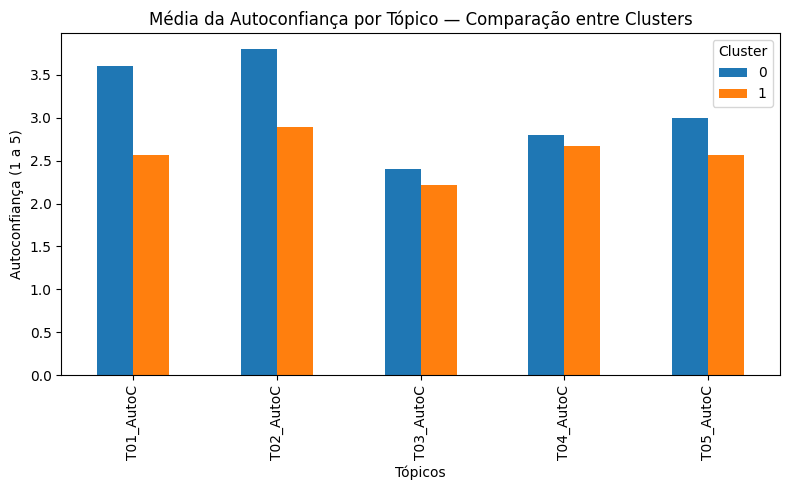

In [ ]:
medias_auto.T.plot(kind='bar', figsize=(8,5))
plt.title("Média da Autoconfiança por Tópico — Comparação entre Clusters")
plt.ylabel("Autoconfiança (1 a 5)")
plt.xlabel("Tópicos")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


In [ ]:
# Selecionar colunas de score fuzzy
score_cols = ['T01_Score', 'T02_Score', 'T03_Score', 'T04_Score', 'T05_Score']

# Calcular médias por cluster
medias_score = df.groupby('cluster_diag')[score_cols].mean().round(1)

print("Média dos Scores Fuzzy por cluster:")
display(medias_score)


Média dos Scores Fuzzy por cluster:


,T01_Score,T02_Score,T03_Score,T04_Score,T05_Score
cluster_diag,,,,,
0,84.0,76.8,40.8,41.8,55.2
1,57.1,51.0,30.8,30.0,40.3


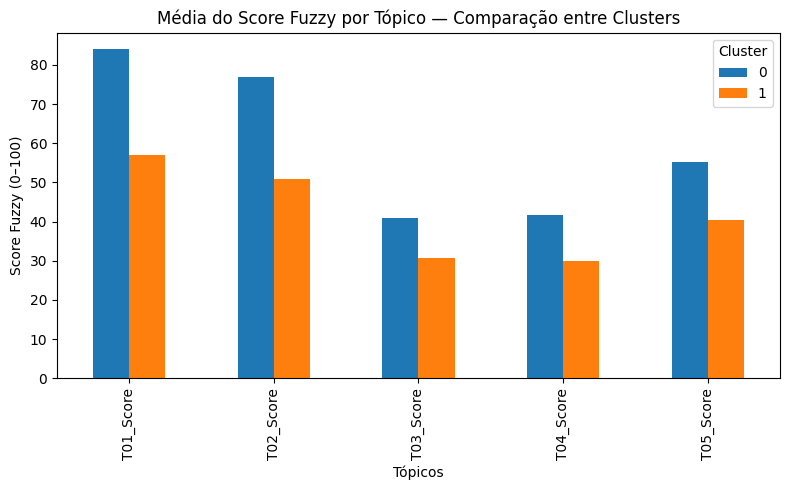

In [ ]:
medias_score.T.plot(kind='bar', figsize=(8,5))
plt.title("Média do Score Fuzzy por Tópico — Comparação entre Clusters")
plt.ylabel("Score Fuzzy (0–100)")
plt.xlabel("Tópicos")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd

trilhas_cols = ['T01_Trilha', 'T02_Trilha', 'T03_Trilha', 'T04_Trilha', 'T05_Trilha']

for col in trilhas_cols:
    print(f"\n=== Teste Qui-quadrado para {col} ===")

    tabela = pd.crosstab(df['cluster_diag'], df[col])
    print("Tabela de contingência:")
    display(tabela)

    try:
        chi2, p, dof, exp = chi2_contingency(tabela)

        print(f"Qui-quadrado = {chi2:.4f}")
        print(f"p-valor = {p:.4f}")

        alpha = 0.05
        if p < alpha:
            print("Conclusão: diferença significativa entre clusters nas trilhas (p < 0.05)")
        else:
            print("Conclusão: SEM diferença significativa entre clusters (p >= 0.05)")

    except Exception as e:
        print("Erro no teste (provavelmente células com frequência zero):", e)



=== Teste Qui-quadrado para T01_Trilha ===
Tabela de contingência:


T01_Trilha,DESAFIO,REFORCO,REGULAR
cluster_diag,,,
0,5,0,0
1,4,1,4


Qui-quadrado = 4.3210
p-valor = 0.1153
Conclusão: SEM diferença significativa entre clusters (p >= 0.05)

=== Teste Qui-quadrado para T02_Trilha ===
Tabela de contingência:


T02_Trilha,DESAFIO,REFORCO,REGULAR
cluster_diag,,,
0,4,0,1
1,3,1,5


Qui-quadrado = 2.9037
p-valor = 0.2341
Conclusão: SEM diferença significativa entre clusters (p >= 0.05)

=== Teste Qui-quadrado para T03_Trilha ===
Tabela de contingência:


...

Qui-quadrado = 2.9296
p-valor = 0.2311
Conclusão: SEM diferença significativa entre clusters (p >= 0.05)

=== Teste Qui-quadrado para T04_Trilha ===
Tabela de contingência:


T04_Trilha,DESAFIO,REFORCO,REGULAR
cluster_diag,,,
0,1,2,2
1,1,6,2


Qui-quadrado = 0.9333
p-valor = 0.6271
Conclusão: SEM diferença significativa entre clusters (p >= 0.05)

=== Teste Qui-quadrado para T05_Trilha ===
Tabela de contingência:


T05_Trilha,DESAFIO,REFORCO,REGULAR
cluster_diag,,,
0,2,1,2
1,3,5,1


Qui-quadrado = 2.2400
p-valor = 0.3263
Conclusão: SEM diferença significativa entre clusters (p >= 0.05)


Descritivo UX por cluster:


UX_mean                             UX_sum                     
               count   mean    std    min    max  count  mean    std min max
cluster_diag                                                                
0                  5  3.229  0.690  2.143  3.857      5  22.6  4.827  15  27
1                  9  3.429  0.958  1.143  4.286      9  24.0  6.708   8  30

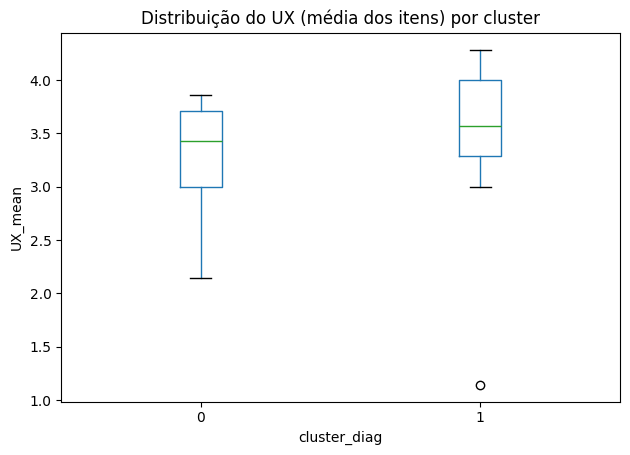

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ux_cols = ['ux1','ux2','ux3','ux4','ux5','ux6','ux7']

# garantir numérico (caso esteja como texto)
df[ux_cols] = df[ux_cols].apply(pd.to_numeric, errors='coerce')

# score geral (média dos itens) e também soma (opcional)
df['UX_mean'] = df[ux_cols].mean(axis=1)
df['UX_sum']  = df[ux_cols].sum(axis=1)

# descritivo por cluster
desc_ux = df.groupby('cluster_diag')[['UX_mean','UX_sum']].agg(['count','mean','std','min','max']).round(3)
print("Descritivo UX por cluster:")
display(desc_ux)

# gráfico: distribuição do UX_mean por cluster
df.boxplot(column='UX_mean', by='cluster_diag', grid=False)
plt.title("Distribuição do UX (média dos itens) por cluster")
plt.suptitle("")
plt.xlabel("cluster_diag")
plt.ylabel("UX_mean")
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu

ux0 = df[df['cluster_diag']==0]['UX_mean'].dropna()
ux1 = df[df['cluster_diag']==1]['UX_mean'].dropna()

print("UX_mean - Cluster 0:", ux0.values)
print("UX_mean - Cluster 1:", ux1.values)

# Normalidade
w0, p0 = shapiro(ux0)
w1, p1 = shapiro(ux1)
print(f"\nShapiro Cluster 0: W={w0:.4f}, p={p0:.4f}")
print(f"Shapiro Cluster 1: W={w1:.4f}, p={p1:.4f}")

alpha = 0.05
normal = (p0 > alpha) and (p1 > alpha)

if normal:
    # Homogeneidade de variâncias
    statL, pL = levene(ux0, ux1)
    print(f"\nLevene: stat={statL:.4f}, p={pL:.4f}")

    equal_var = pL > alpha
    t, p = ttest_ind(ux0, ux1, equal_var=equal_var)
    print("\nT-test independente (UX_mean)")
    print(f"t={t:.4f}, p={p:.4f} | equal_var={equal_var}")

    # Cohen's d
    import numpy as np
    n0, n1 = len(ux0), len(ux1)
    s0 = np.std(ux0, ddof=1)
    s1 = np.std(ux1, ddof=1)
    pooled = np.sqrt(((n0-1)*s0**2 + (n1-1)*s1**2) / (n0+n1-2))
    d = (np.mean(ux0) - np.mean(ux1)) / pooled
    print(f"Cohen's d = {d:.4f}")

else:
    # Não-paramétrico
    u, p = mannwhitneyu(ux0, ux1, alternative='two-sided')
    print("\nMann–Whitney U (UX_mean)")
    print(f"U={u:.4f}, p={p:.4f}")

    # efeito (r) a partir do z aproximado (boa prática com Mann-Whitney)
    import math
    n0, n1 = len(ux0), len(ux1)
    mu_u = n0*n1/2
    sigma_u = math.sqrt(n0*n1*(n0+n1+1)/12)
    z = (u - mu_u) / sigma_u
    r = abs(z) / math.sqrt(n0+n1)
    print(f"Efeito r ≈ {r:.4f}")


UX_mean - Cluster 0: [3.85714286 2.14285714 3.71428571 3.         3.42857143]
UX_mean - Cluster 1: [3.28571429 1.14285714 3.71428571 4.28571429 3.57142857 4.
 3.         3.57142857 4.28571429]

Shapiro Cluster 0: W=0.9047, p=0.4364
Shapiro Cluster 1: W=0.7985, p=0.0197

Mann–Whitney U (UX_mean)
U=17.0000, p=0.5031
Efeito r ≈ 0.1960


In [ ]:
# Cronbach's alpha para ux1..ux7
X = df[ux_cols].dropna()
k = X.shape[1]
item_vars = X.var(axis=0, ddof=1)
total_var = X.sum(axis=1).var(ddof=1)

alpha_cronbach = (k/(k-1)) * (1 - item_vars.sum()/total_var)

print(f"Cronbach's alpha (UX) = {alpha_cronbach:.4f}")
print(f"N válido (sem NA) = {len(X)}")

Cronbach's alpha (UX) = 0.8038
N válido (sem NA) = 14
